# Data Visualization and Analysis

This Jupyter Notebook is designed to help visualize and analyze a dataset. We will use various Python libraries to create visual representations of the data, which will help us better understand and interpret the information. By the end of this notebook, you should have a clearer understanding of the dataset and be able to draw meaningful insights from it.

## Dataset
* Data of train containg training and validation
* Data of test is the one for the submition
* 401059 records
* 

In [27]:
import h5py
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import missingno as msno


BASE_PATH = "./dataset_aml"

In [11]:
# Train + Valid
df = pd.read_csv(f'{BASE_PATH}/train-metadata.csv')
df = df.ffill()

# Testing
testing_df = pd.read_csv(f'{BASE_PATH}/test-metadata.csv')
testing_df = testing_df.ffill()

training_validation_hdf5 = h5py.File(f"{BASE_PATH}/train-image.hdf5", 'r')
testing_hdf5 = h5py.File(f"{BASE_PATH}/test-image.hdf5", 'r')

/tmp/ipykernel_1607/780199399.py:2: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{BASE_PATH}/train-metadata.csv')


In [30]:
df

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401054,ISIC_9999937,0,IP_1140263,70.0,male,anterior torso,6.80,TBP tile: close-up,3D: XP,22.574335,...,IL_9520694,Benign,Benign,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular","Blue nevus, Cellular",<1/mm^2,0.6,99.999988
401055,ISIC_9999951,0,IP_5678181,60.0,male,posterior torso,3.11,TBP tile: close-up,3D: white,19.977640,...,IL_9520694,Benign,Benign,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular","Blue nevus, Cellular",<1/mm^2,0.6,99.999820
401056,ISIC_9999960,0,IP_0076153,65.0,female,anterior torso,2.05,TBP tile: close-up,3D: XP,17.332567,...,IL_9852274,Benign,Benign,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular","Blue nevus, Cellular",<1/mm^2,0.6,99.999416
401057,ISIC_9999964,0,IP_5231513,30.0,female,anterior torso,2.80,TBP tile: close-up,3D: XP,22.288570,...,IL_9852274,Benign,Benign,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular","Blue nevus, Cellular",<1/mm^2,0.6,100.000000


## Data visualization
### Class balances

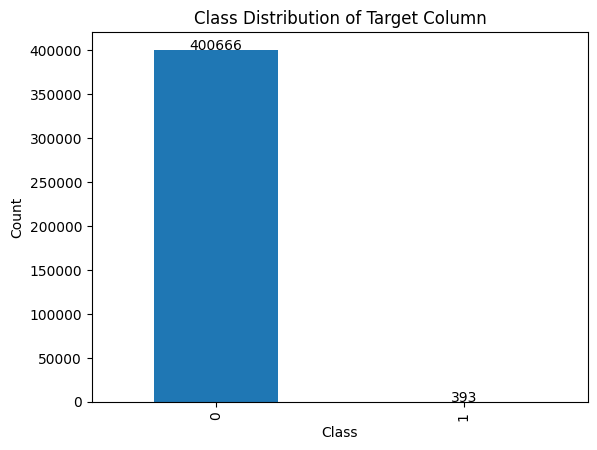

In [26]:
# Plotting the class distribution of the 'target' column
df['target'].value_counts().plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution of Target Column')

# Adding number values on top of the bars
for index, value in enumerate(df['target'].value_counts()):
    plt.text(index, value, str(value), ha='center')

plt.show()

### Missing data

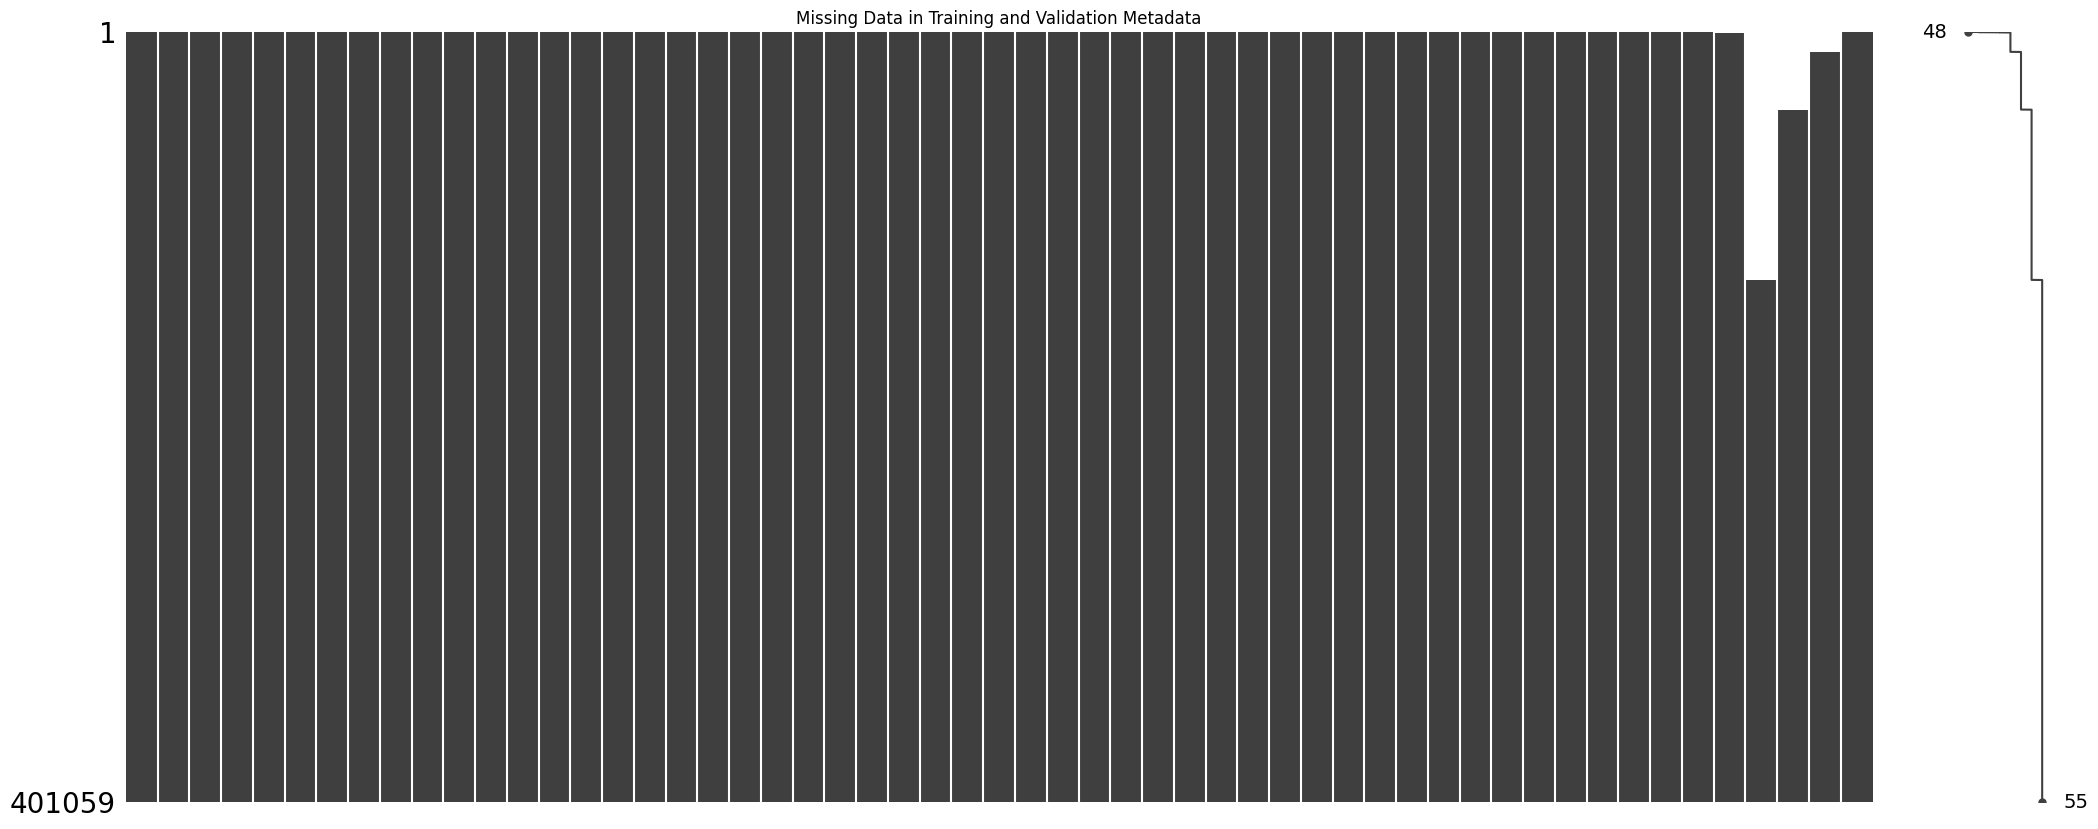

lesion_id             0.000249
iddx_2                0.041390
iddx_3                0.041390
iddx_4                0.067820
iddx_5               32.206982
mel_mitotic_index    10.088042
mel_thick_mm          2.593135
dtype: float64


In [29]:

# Visualize missing data for the training and validation dataset
msno.matrix(df)
plt.title('Missing Data in Training and Validation Metadata')
plt.show()

# Calculate the percentage of missing data for each column
missing_data_percentage = df.isnull().mean() * 100

# Filter columns with missing data
missing_data_columns = missing_data_percentage[missing_data_percentage > 0]

# Print the column names and the percentage of missing data
print(missing_data_columns)
# # Visualize missing data for the testing dataset
# msno.matrix(testing_df)
# plt.title('Missing Data in Testing Metadata')
# plt.show()

### Correlations

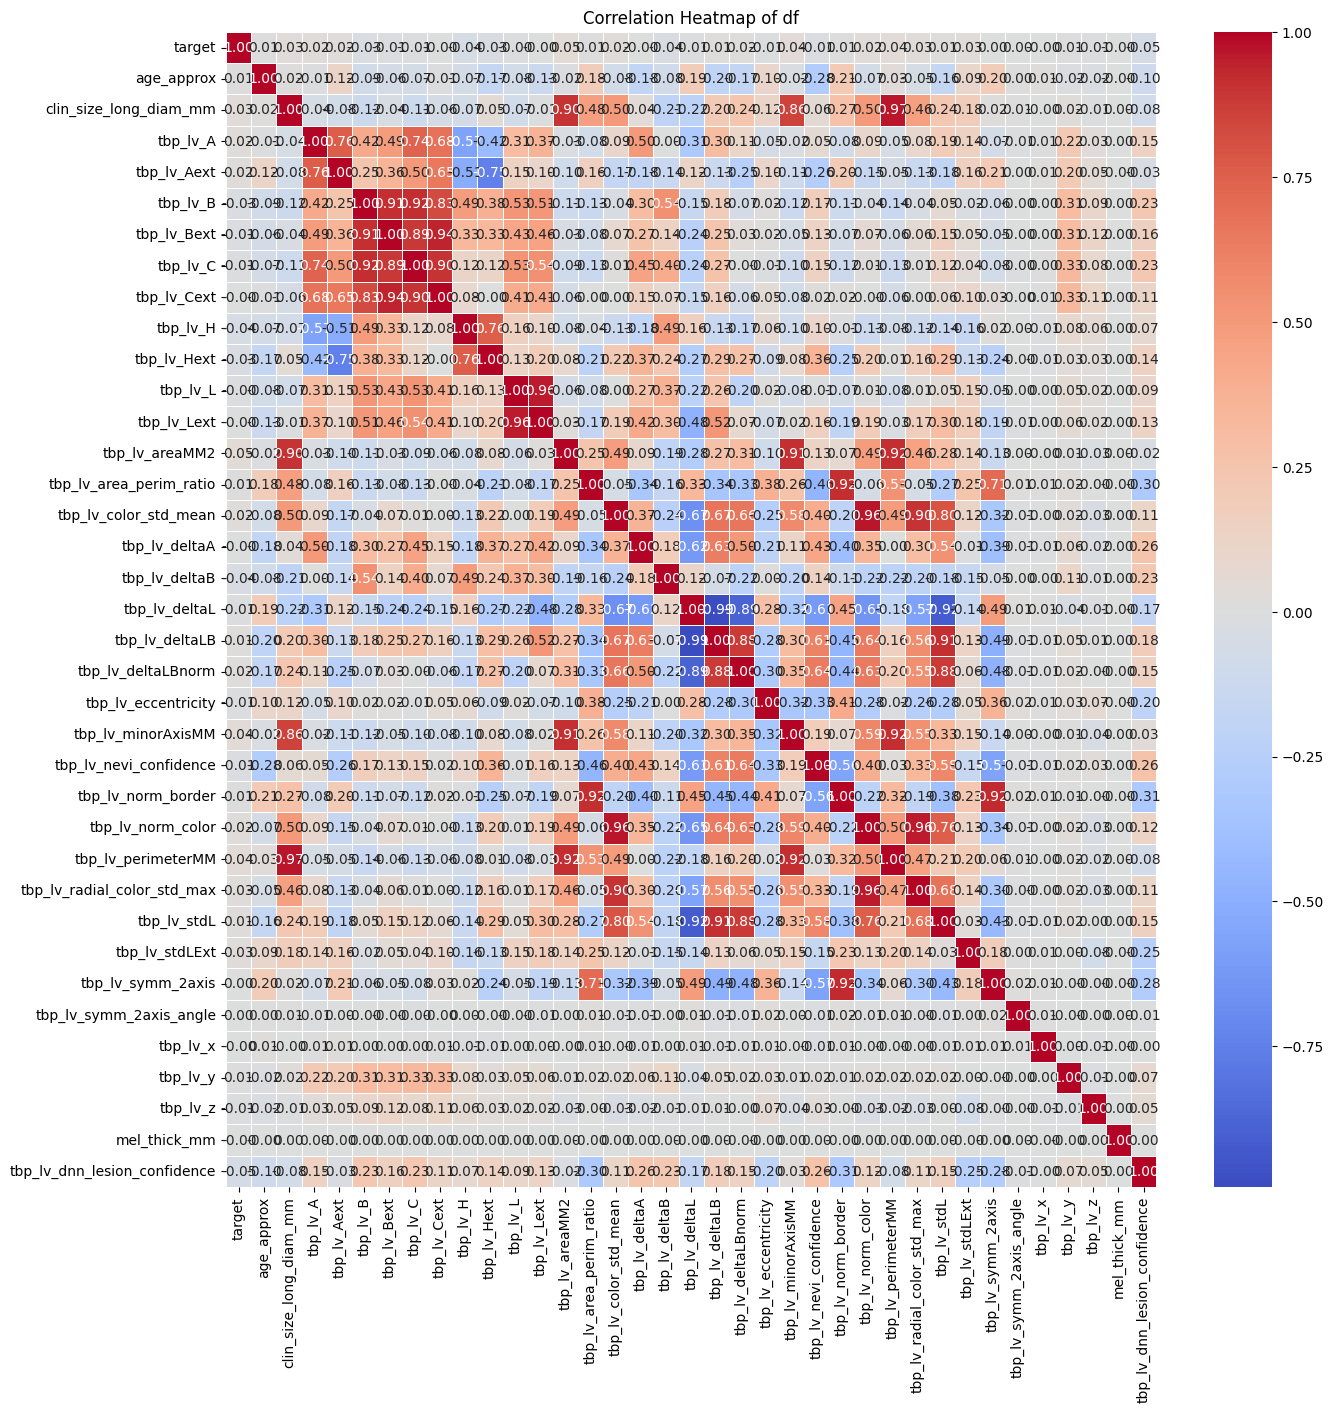

In [36]:
import seaborn as sns


# Calculate the correlation matrix
# Select only numerical columns
numerical_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of df')
plt.show()

/tmp/ipykernel_1607/2879822844.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_30_features], y=top_30_features, palette='viridis')


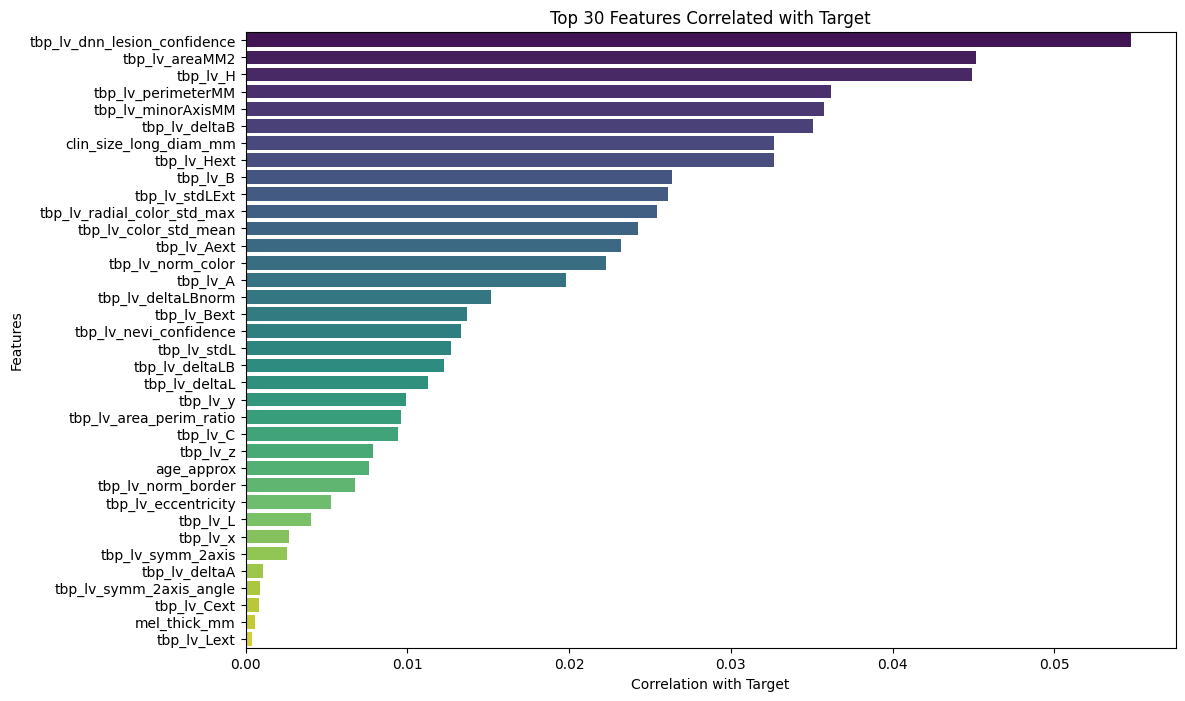

In [41]:
# Calculate the correlation of each feature with 'target'
correlations = numerical_df.corr()['target'].abs().sort_values(ascending=False)

# Select the top 30 features
top_30_features = correlations.index[1:41]  # Exclude 'target' itself

# Plot the top 30 correlated features
plt.figure(figsize=(12, 8))
sns.barplot(x=correlations[top_30_features], y=top_30_features, palette='viridis')
plt.xlabel('Correlation with Target')
plt.ylabel('Features')
plt.title('Top 30 Features Correlated with Target')
plt.show()

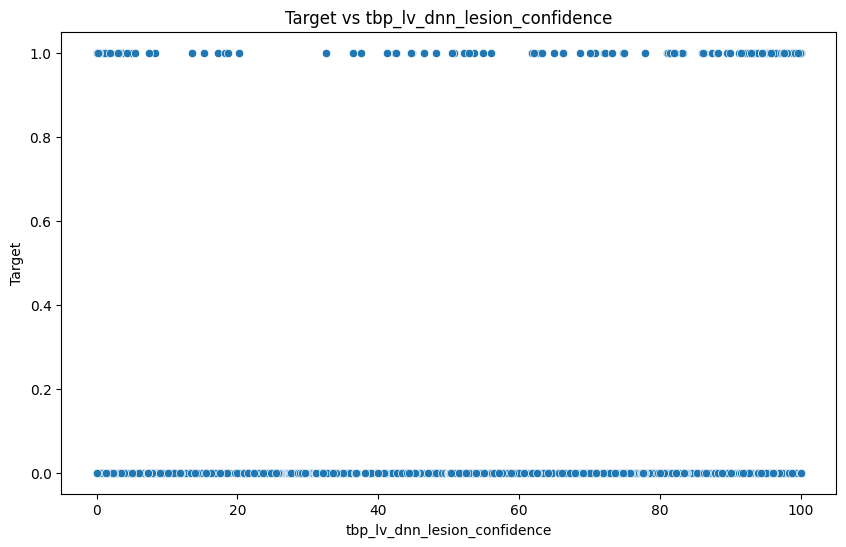

In [42]:
# Get the top feature correlated to the target
top_feature = correlations.index[1]

# Plot target vs top feature
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[top_feature], y=df['target'])
plt.xlabel(top_feature)
plt.ylabel('Target')
plt.title(f'Target vs {top_feature}')
plt.show()

Byte String: b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00'....
Image:


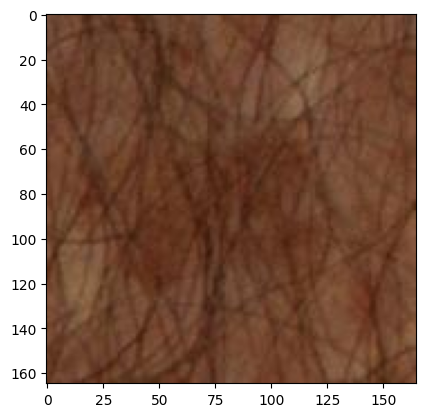

In [18]:
isic_id = df.isic_id.iloc[100]

# Image as Byte String
byte_string = training_validation_hdf5[isic_id][()]
print(f"Byte String: {byte_string[:20]}....")

# Convert byte string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

print("Image:")
image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)[...,::-1] # reverse last axis for bgr -> rgb
plt.imshow(image);

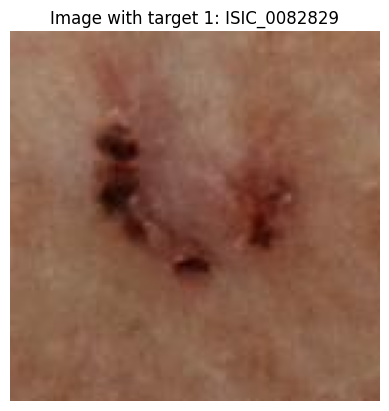

In [31]:
# Filter the dataframe to get an isic_id with target 1
isic_id_target_1 = df[df['target'] == 1].iloc[0]['isic_id']

# Retrieve the image as a byte string
byte_string_target_1 = training_validation_hdf5[isic_id_target_1][()]

# Convert byte string to numpy array
nparr_target_1 = np.frombuffer(byte_string_target_1, np.uint8)

# Decode the image
image_target_1 = cv2.imdecode(nparr_target_1, cv2.IMREAD_COLOR)[..., ::-1]  # reverse last axis for bgr -> rgb

# Plot the image
plt.imshow(image_target_1)
plt.title(f'Image with target 1: {isic_id_target_1}')
plt.axis('off')
plt.show()